In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

from _utils.export import export_figure

VERB = True

BASE_DIR = os.path.abspath(os.path.join(os.path.dirname("."), ".."))
EXPORTS_DIR = f"{BASE_DIR}/_exports/01_03_manifold_learning"
os.makedirs(EXPORTS_DIR, exist_ok=True)

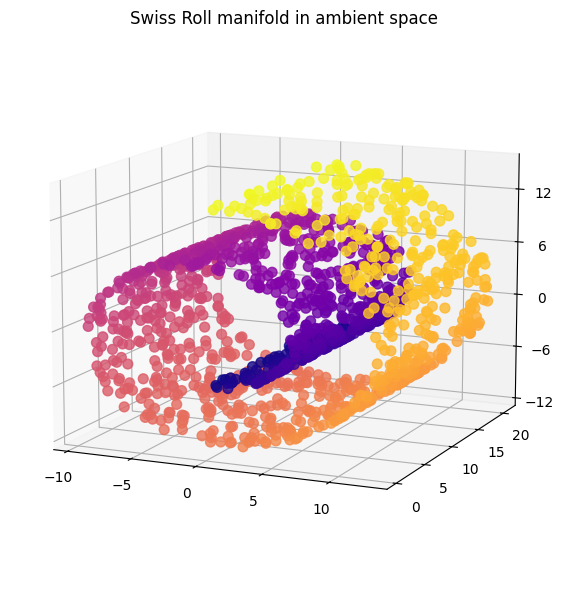

In [2]:
from _utils.data_manifold import generate_swiss_roll
from _utils.plotting import visualize_manifold

X, y = generate_swiss_roll()
visualize_manifold(X, y, "Swiss Roll manifold in ambient space");

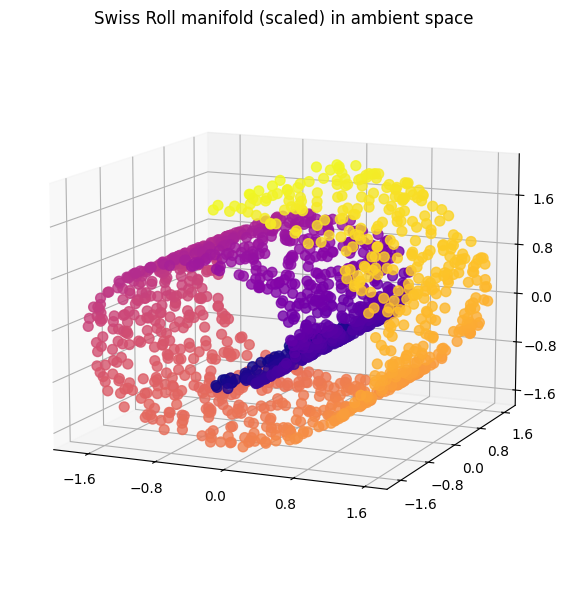

Figure saved to `_exports` folder as `01_03_manifold_01.png`


In [3]:
# scale data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

del X

fig, ax = visualize_manifold(X_scaled, y, "Swiss Roll manifold (scaled) in ambient space")


# export fig
export_figure(fig, EXPORTS_DIR, "01_03_manifold_01.png")

In [4]:
from _utils.som_embedding import SOM_Embedding
from _utils.som_hyparams import obtain_som_hyparams

hyparams = obtain_som_hyparams(X_scaled, verb=VERB)
hyparams["num_iteration"] = 28
embedding = SOM_Embedding(**hyparams, verb=VERB) \
    .fit(X_scaled)

SOM grid recommended total node count, based on 1500 training data points: 194
SOM grid recommended dimensions: width=15, height=14
SOM hyperparameters determined as (d1, d2, sigma, learning rate, num. iteration): 14 15 5.0 0.6 20
 [ 42000 / 42000 ] 100% - 0:00:00 left 
 quantization error: 0.42592063642911593

Brief quality of SOM:
Quantization error:	0.42592063642911593
Topographic error:	0.008
Quantization error (rounded):	0.426
Topographic error (rounded):	0.008


In [5]:
# test convergence
"""
from _utils.som import plot_som_convergence_over_epochs
MQEs, TEs = plot_som_convergence_over_epochs(X_scaled, epoch_min=1, epoch_max=30, step=1, **hyparams)

print(np.round(MQEs, 3))
"""

'\nfrom _utils.som import plot_som_convergence_over_epochs\nMQEs, TEs = plot_som_convergence_over_epochs(X_scaled, epoch_min=1, epoch_max=30, step=1, **hyparams)\n\nprint(np.round(MQEs, 3))\n'

In [6]:
som = embedding.som_

node_weights = som.get_weights()
node_weights_flat = node_weights.reshape(-1, node_weights.shape[2])

Figure saved to `_exports` folder as `01_03_manifold_02.png`


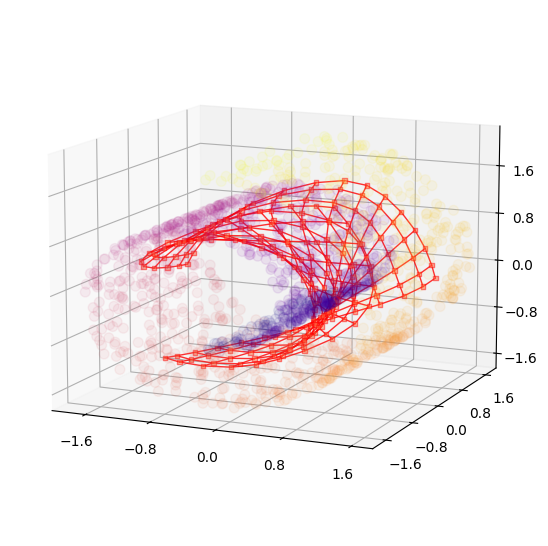

In [7]:
from _utils.plotting import place_som_lattice

data_plot_style = {
    "alpha": 0.08,
}

fig, ax = visualize_manifold(X_scaled, y, "SOM embedding of\nSwiss Roll manifold (scaled) in ambient space", plot_style_args=data_plot_style, hold_on=True)
place_som_lattice(ax, node_weights, node_weights_flat)


# export fig
export_figure(fig, EXPORTS_DIR, "01_03_manifold_02.png")

## Lilypond

In [8]:
from lilypond.basin import Basin
from _utils.constants import RANDOM_SEED

basin = Basin(som, X_scaled, random_seed=RANDOM_SEED) \
    .prepare()

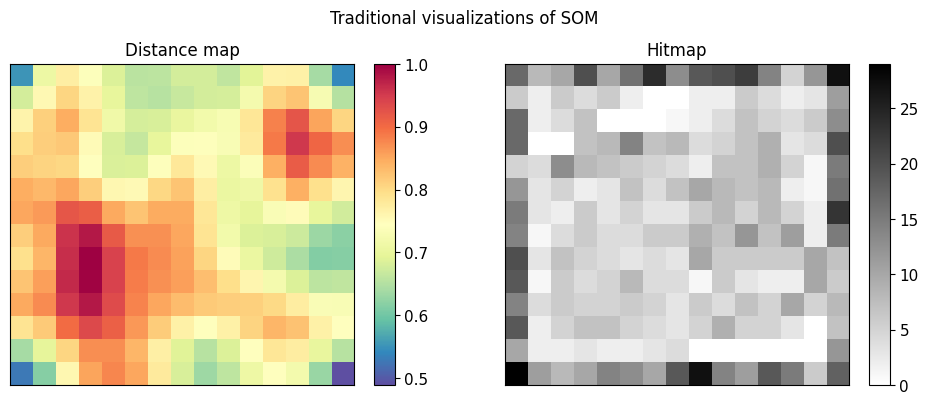

Figure saved to `_exports` folder as `01_03_lilypond_00.png`


In [9]:
fig, _ = basin.legacy_pond().visualize()

# export fig
export_figure(fig, EXPORTS_DIR, "01_03_lilypond_00.png")

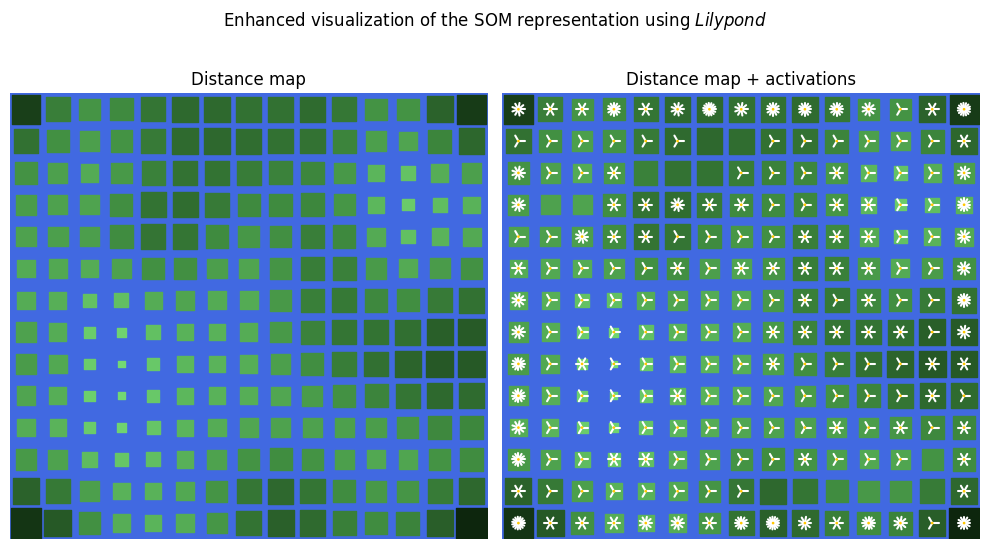

Figure saved to `_exports` folder as `01_03_lilypond_01.png`


In [10]:
from lilypond.basin import Basin
from _utils.constants import RANDOM_SEED

figsize = (10, 6)
coloring_strategy = "distance_map"

pad_style = {
    "marker": "s",
	"gap": -.15,
}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=figsize)

basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.style_pad(**pad_style) \
	.style_petal(hide=True) \
    .style_flood(underwater_opacity=.4) \
	.observe(return_fig=True, ax=ax0, title="Distance map")

basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.discretize_petals(n_bins=5) \
	.style_pad(**pad_style) \
	.style_petal(magnifier=3, width=1.5, size_base=.4) \
    .style_flood(underwater_opacity=.4) \
	.observe(return_fig=True, ax=ax1, title="Distance map + activations")

for ax in (ax0, ax1):
	ax.set_aspect('equal')
	ax.axis("off")

plt.suptitle("Enhanced visualization of the SOM representation using $Lilypond$")
plt.tight_layout()
plt.show()


# export fig
export_figure(fig, EXPORTS_DIR, "01_03_lilypond_01.png")

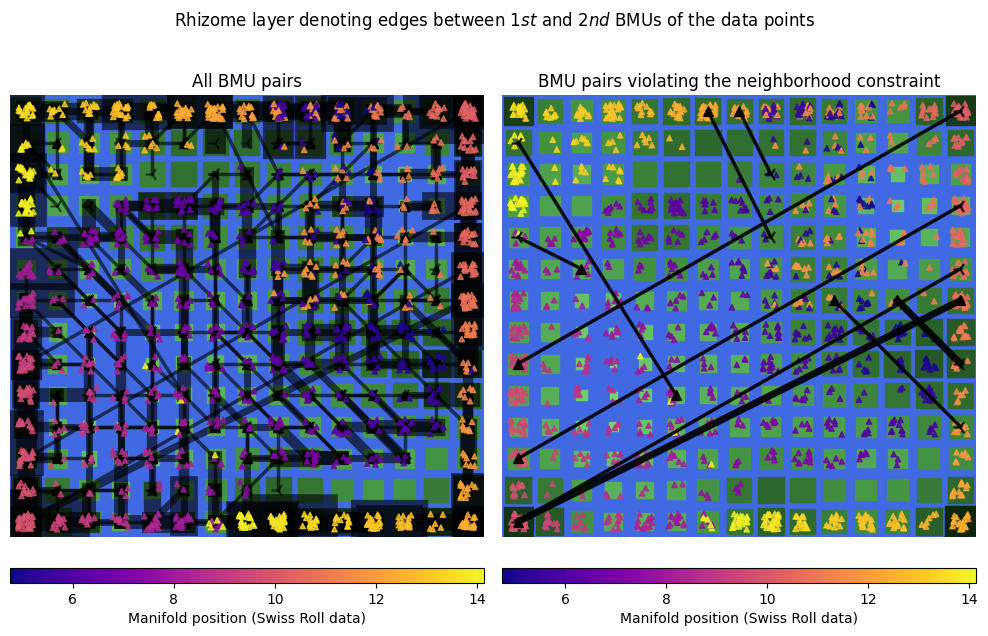

Figure saved to `_exports` folder as `01_03_lilypond_02.png`


In [11]:
figsize = (10, 6)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=figsize)

cmap = "plasma"

rhizome_style = {
    "zorder": 11,
	"marker_start": "^",
	"marker_end": "3",
	"opacity": .6,
	"linewidth": 2.5,
}

attract_style = {
    "cmap": cmap,
    "cmap_values": y,
    "cmap_label": "Manifold position",
    "label": "Swiss Roll data",
    "zorder": 21,
    "marker": "^",
    "size_base": 15,
    "opacity": .8,
    "subsample_ratio": None,
}

basin.pond() \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.style_pad(**pad_style) \
	.style_petal(hide=True) \
	.style_flood(underwater_opacity=.4) \
	.style_rhizome(**rhizome_style) \
	.see_rhizome(mode="all", ax=ax0) \
	.attract(X_scaled, **attract_style) \
	.observe(return_fig=True, ax=ax0, title="All BMU pairs")

pond1 = basin.pond()
pond1 \
    .set_coloring_strategy(coloring_strategy) \
    .flood(below_activations=0) \
	.style_pad(**pad_style) \
	.style_petal(hide=True) \
	.style_flood(underwater_opacity=.4) \
	.style_rhizome(**{**rhizome_style, "zorder": 22, "opacity": .9}) \
	.see_rhizome(mode="violating", ax=ax1) \
	.attract(X_scaled, **attract_style) \
	.observe(return_fig=True, ax=ax1, title="BMU pairs violating the neighborhood constraint")

for ax in (ax0, ax1):
	ax.set_aspect('equal')
	ax.axis("off")
    
plt.suptitle("Rhizome layer denoting edges between $1st$ and $2nd$ BMUs of the data points")
plt.tight_layout()
plt.show()


# export fig
export_figure(fig, EXPORTS_DIR, "01_03_lilypond_02.png")

In [12]:
import pickle
dataset_name = "Swiss Roll"
pickle.dump(basin, open(f"./_exports/basin_{dataset_name}.pkl", "wb"))

In [13]:
from _utils.som_evaluation import calc_som_trustworthiness_umatrix
np.set_printoptions(legacy='1.25')

trustworthiness_umatrix_list = []
k_candidates = np.arange(5, 50+1, 5)

for k in k_candidates:
	trustworthiness_umatrix_list.append(calc_som_trustworthiness_umatrix(basin.som, basin.data, k))

print(np.array(trustworthiness_umatrix_list).round(4))

[0.9894 0.9886 0.9882 0.9879 0.9876 0.9875 0.9869 0.9867 0.9868 0.987 ]


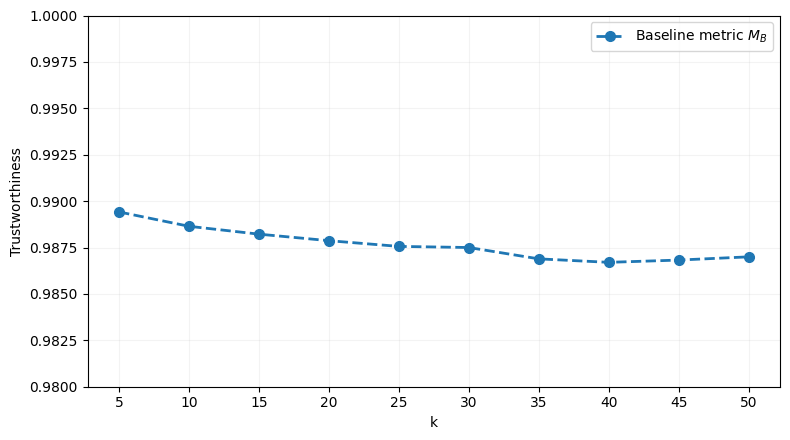

In [14]:
plt.figure(figsize=(8, 4.5))
ax = plt.gca()

# plt.plot(k_candidates, trustworthiness_umatrix_altered_list, marker="o", markersize=7.0, linestyle="solid", linewidth=2.0, label="Proposal's metric $M_P$")
plt.plot(k_candidates, trustworthiness_umatrix_list, marker="o", markersize=7.0, linestyle="dashed", linewidth=2.0, label="Baseline metric $M_B$")

ax.set_ylim([0.98, 1])
ax.set_xlabel("k")
ax.set_ylabel("Trustworthiness")
ax.set_xticks(k_candidates)

plt.grid(alpha=.15)
plt.legend()
plt.tight_layout()
plt.show()